In [ ]:
# Check correct virtual environment
!pip list

In [ ]:
# Imports
import os
import httpx
import asyncio # Will be needed outside ipynb
import copy
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langgraph.graph import StateGraph, END, START
from logger import LOG_TYPES, logger
load_dotenv()

if "TEST_VARIABLE" in os.environ:
    logger(".env is working", LOG_TYPES.SUCCESS)
else:    
    logger(".env is not working", LOG_TYPES.ERROR)

SUCCESS: .env is working


In [2]:
class AgentState(TypedDict):
    """State of the agent."""
    user_uuid: str
    last_user_message: str
    data: dict

async def classify_message_intent(state: AgentState) -> AgentState:
    """Classify the intent of the message."""

    new_state:AgentState = copy.deepcopy(state)

    try:
        url = os.getenv("INTENT_CLASSIFIER_API_URL")
        if not url:
            logger("Error: INTENT_CLASSIFIER_API_URL not set", LOG_TYPES.ERROR)
            new_state['data']['classification_error'] = "INTENT_CLASSIFIER_API_URL not set"
            return new_state
        
        # Prepare the payload
        logger(state["last_user_message"], LOG_TYPES.INFORMATION)
        payload = {"sentence": state["last_user_message"]}
        
        # Make the POST request
        async with httpx.AsyncClient(timeout=10.0) as client:
            resp = await client.post(url, json=payload)
            resp.raise_for_status()
            data = resp.json()

        description = data.get("description")
        if not description:
            logger("Error: Invalid response format (missing 'description')", LOG_TYPES.ERROR)
            new_state['data']['classification_error'] = "Invalid response format"
            return new_state

        logger(f"Message: '{state['last_user_message']}' classified as: {description}", LOG_TYPES.SUCCESS)

        new_state['data']['classified_intent'] = description
        return new_state
        
    except httpx.RequestError as e:
        logger(f"API request failed: {e}", LOG_TYPES.ERROR)
        new_state['data']['classification_error'] = "API request failed"
        return new_state
    except httpx.HTTPStatusError as e:
        logger(f"API returned error status: {e.response.status_code}", LOG_TYPES.ERROR)
        new_state['data']['classification_error'] = "API request failed"
        return new_state
    except ValueError:
        logger("Response was not valid JSON", LOG_TYPES.ERROR)
        new_state['data']['classification_error'] = "Invalid JSON response"
        return new_state

def route_after_classification(state: AgentState) -> str:
    """Route based on classification result."""
    if 'classification_error' in state['data']:
        return "error"
    
    classified_intent = state['data'].get('classified_intent', '')
    
    return classified_intent
    
async def recommend_product(state: AgentState) -> AgentState:
    """Recommend a product based on the message."""

    newstate:AgentState = copy.deepcopy(state)

    # Placeholder implementation
    logger(f"Recommending product for message: '{state['last_user_message']}'", LOG_TYPES.INFORMATION)
    newstate['data']['Recommended Product'] = "Recommended Product: XYZ"
    return newstate

def send_response_to_user(state: AgentState) -> AgentState:
    """Send a response back to the user."""
    # Placeholder implementation
    logger(f"Sending response to user {state['user_uuid']}: '{state['data'].get('Recommended Product')}'", LOG_TYPES.INFORMATION)
    return copy.deepcopy(state)

graph = StateGraph(AgentState)
graph.add_node("intent_classifier", classify_message_intent)
graph.add_node("product_recommender", recommend_product)
graph.add_node("send_response_to_user", send_response_to_user)

graph.add_edge(START, "intent_classifier")
graph.add_conditional_edges(
    "intent_classifier",
    route_after_classification,
    {
        "Product recommendation": "product_recommender",
        "error": "send_response_to_user"
    }
)
graph.add_edge("product_recommender", "send_response_to_user")
graph.add_edge("send_response_to_user", END)

bot = graph.compile()

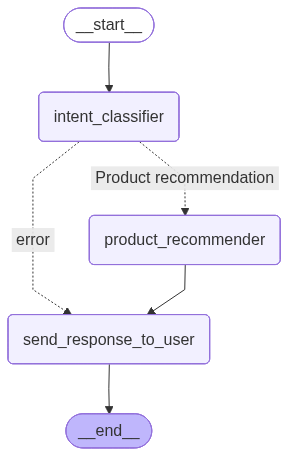

In [3]:
# Visualize Flow
from IPython.display import Image, display
display(Image(bot.get_graph().draw_mermaid_png())) # visualize the graph

In [4]:
input = {
    "user_uuid": "12345",
    "last_user_message": "I want Amul dark chocolate",
    "data": {}}

await bot.ainvoke(input)

INFORMATION: I want Amul dark chocolate
SUCCESS: Message: 'I want Amul dark chocolate' classified as: Product recommendation
INFORMATION: Recommending product for message: 'I want Amul dark chocolate'
INFORMATION: Sending response to user 12345: 'Recommended Product: XYZ'


{'user_uuid': '12345',
 'last_user_message': 'I want Amul dark chocolate',
 'data': {'classified_intent': 'Product recommendation',
  'Recommended Product': 'Recommended Product: XYZ'}}